In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table; 
from scipy.interpolate import RectBivariateSpline

In [56]:
z_axis_interp = np.linspace(0, 4, 30)
m_max_axis_interp = np.linspace(21, 24, 10)
f = np.zeros([len(z_axis_interp), len(m_max_axis_interp)])

z_arr_file = np.linspace(0, 6, 100)
m_max_arr_file = [21, 22, 23, 23.3, 23.5, 24]
store_f = np.zeros([len(z_arr_file), len(m_max_arr_file)])

name_file = [21, 22, 23, '23p3',  '23p5', 24]
for i, rmax in enumerate(name_file):
    t = Table.read(f"qlf_rmax_{rmax}.ecsv", format="ascii.ecsv")
    
    if rmax == '23p3': 
        rmax_ = '23p5'
    else: rmax_ = rmax

    z = t['z']
    qlf =  t[f'qlf_{rmax_}']
    qlf_interp = np.interp(z_arr_file, z, qlf)
    arr = np.arange(0, 4.05, 0.05)
    ntot = np.sum(np.interp(arr[arr >= 2.1], z, qlf))
    print(rmax, ntot)
    
    dn_dz = ntot * qlf_interp/np.trapz(qlf_interp,z_arr_file, )
    store_f[:,i] = dn_dz

from scipy.interpolate import RegularGridInterpolator

interp = RectBivariateSpline(
    z_arr_file,
    m_max_arr_file,
    store_f,
    kx=3,
    ky=3
)

Z, M = np.meshgrid(z_axis_interp, m_max_axis_interp, indexing='ij')
f = np.clip(interp.ev(Z, M), 0, 1000000)

21 19.640032008014753
22 43.89568641638076
23 84.36647647271162
23p3 100.9560288754615
23p5 113.92972960383469
24 150.70926946690338


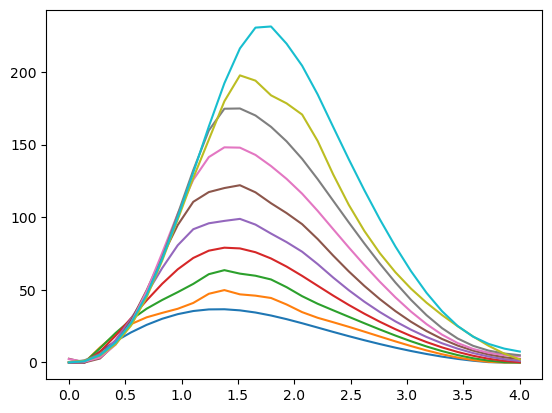

In [53]:
for i, m in enumerate(m_max_axis_interp):
    plt.plot(z_axis_interp, f[:,i])